<a href="https://colab.research.google.com/github/Jawaaa/retail-sales-and-branch-performance/blob/main/Assignment_Day_13_Zahwa_Rizzi_Ani_data_manipulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Jawablah poin-poin assignment berikut
#### perhatikan dengan baik apa yang diminta pada soal

# 1. Anda bekerja sebagai seorang data scientist, atasan anda mengirimkan anda data kepada anda dan meminta untuk memberikan analisa dengan menggunakan semua metode pada data manipulation berikut :
- a. Filtering
- b. Sorting
- c. Grouping / Aggregasi
- d. Join / Merging
- e. Pivot
- f. Crosstab
- g. Appending
- h. Mengeksplor terkait dengan operasi pada Datetime (week, day, dan sebagainya)
### Notes : Sebelum menjawab permintaan diatas, pertama-tama awali dengan mengajukan pertanyaan analisa terlebih dahulu dan tulis insight dari yang anda dapat, **pertanyaan analisa dilakukan pada semua metode data manipulation diatas**

# a. Filtering

> Pertanyaan: Siapa saja pelanggan 'Member' di kota 'Yangon' yang total belanjaannya > 300?







In [ ]:
import pandas as pd
import numpy as np

df_supermarket = pd.read_csv('/content/supermarket_sales.csv')
df_supermarket.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


In [ ]:
df_supermarket.describe()

,Unit price,Quantity,Tax 5%,Total,cogs,gross margin percentage,gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1.000000e+03,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905e+00,15.379369,6.97270
std,26.494628,2.923431,11.708825,245.885335,234.17651,6.131498e-14,11.708825,1.71858
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905e+00,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905e+00,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905e+00,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905e+00,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905e+00,49.650000,10.00000


In [ ]:
print("\n--- a. FILTERING ANALYSIS ---")
high_value_yangon = df_supermarket[(df_supermarket['Customer type'] == 'Member') &
                       (df_supermarket['City'] == 'Yangon') &
                       (df_supermarket['Total'] > 500)]

print(f" Pelanggan VIP Yangon ditemukan: {len(high_value_yangon)} transaksi")
print(high_value_yangon[['Customer type', 'City', 'Total']].head())


--- a. FILTERING ANALYSIS ---
 Pelanggan VIP Yangon ditemukan: 39 transaksi
    Customer type    City     Total
0          Member  Yangon  548.9715
16         Member  Yangon  506.6355
58         Member  Yangon  759.6750
105        Member  Yangon  931.0350
113        Member  Yangon  548.7615


**Jawaban Insight dari pertanyaan Filtering:**


> Sesuai dengan data statistik yang menunjukkan rata-rata belanja konsumen berada di angka 322, penggunaan batas 300 atau 500 sangat strategis untuk memisahkan kelompok konsumen "belanja besar" dari pembeli harian biasa. Fokus pada wilayah atau pelanggan dengan transaksi di atas 500 memungkinkan tim pemasaran untuk tidak "bakar duit" dengan memberikan promo ke semua orang, melainkan lebih tepat sasaran.

> Strategi marketing di masa depan bisa diarahkan pada pemberian voucher belanja kelipatan atau kupon diskon untuk kunjungan berikutnya khusus bagi mereka yang transaksinya menyentuh angka tersebut. Dengan begitu, supermarket bisa menjamin adanya repeat order dan meningkatkan frekuensi kunjungan dari kelompok konsumen yang memang terbukti memiliki daya beli tinggi. Hal ini jauh lebih efektif untuk menjaga stabilitas omset cabang karena kita berhasil mengunci loyalitas orang-orang yang paling banyak berkontribusi terhadap pendapatan toko melalui insentif yang relevan.



# b. Sorting


> Bagaimana tren distribusi total penjualan dari bulan ke bulan, dan di bulan mana supermarket mencatatkan pendapatan tertinggi?



In [ ]:
import pandas as pd

# Samakan terlebih dahulu format tanggalnya jadi perbulan
df_supermarket['Date'] = pd.to_datetime(df_supermarket['Date'])
df_supermarket['Month'] = df_supermarket['Date'].dt.to_period('M') # Mengambil Bulan & Tahun

# Hitung terlebih dahulu total penjualan tiap bulannya
monthly_sales = df_supermarket.groupby('Month')['Total'].sum().reset_index()

# Urutkan berdasarkan bulan agar kita bisa lihat distribusinya.
sorted_sales = monthly_sales.sort_values(by='Month', ascending=True)

print("\n--- b. SORTING ANALYSIS ---")
print(f" Distribusi Penjualan Per Bulan (Terurut):")
print(sorted_sales)



--- b. SORTING ANALYSIS ---
 Distribusi Penjualan Per Bulan (Terurut):
     Month       Total
0  2019-01  116291.868
1  2019-02   97219.374
2  2019-03  109455.507


**Insight Jawaban Pertanyaan Sorting:**

> Kalau kita perhatikan penjualan dari bulan ke bulan, fluktuasi penjualan cukup terasa meskipun baru berjalan tiga bulan. Di Januari kita berhasil mencatatkan omset tinggi (116k), tapi langsung menurun drastis di Februari ke angka 97k. Ini menunjukkan kalau bisnis kita sangat bergantung pada momen, kemungkinan ada fase pembeli irit belanja setelah pengeluaran besar di awal tahun.

> Tujuan kita memetakan ini adalah untuk menjaga stabilitas operasional. Dengan melihat angka yang kembali naik di Maret (109k), kita jadi tahu kalau penurunan di Februari itu murni faktor musiman, bukan karena performa toko yang memburuk. Jadi, ke depannya kita bisa menyiapkan strategi penahan, seperti promo atau event khusus di bulan-bulan sepi agar pendapatan tidak merosot terlalu jauh.

> Untuk jangka panjang, data ini jadi pelajaran berharga bahwa target penjualan tidak bisa dipukul rata setiap bulan. Manajemen perlu lebih fleksibel dalam mengatur strategi seperti efisiensi biaya di bulan yang lesu, dan stok barang maksimal di bulan-bulan potensial. Dengan pola seperti ini, cash flow perusahaan akan jauh lebih sehat dan terukur sepanjang tahun.


#  c. Grouping / Aggregasi


> Pertanyaan: Bagaimana performa pendapatan, volume penjualan, dan tingkat kepuasan pelanggan jika dilihat berdasarkan kombinasi Kota dan Lini Produk?



In [ ]:
print("\n--- c. GROUPING & AGGREGATION ---")

group_analysis = df_supermarket.groupby(['City', 'Product line']).agg({
    'Total': 'sum',
    'Quantity': 'sum',
    'Rating': 'mean'
}).reset_index()


# Urutkan untuk melihat performa tertinggi
group_analysis = group_analysis.sort_values(by=['City', 'Total'], ascending=[True, False])

print(f" Analisis Agregasi Berdasarkan Kota dan Kategori Produk:")
print(group_analysis.head(10))



--- c. GROUPING & AGGREGATION ---
 Analisis Agregasi Berdasarkan Kota dan Kategori Produk:
        City            Product line       Total  Quantity    Rating
5   Mandalay       Sports and travel  19988.1990       322  6.509677
3   Mandalay       Health and beauty  19980.6600       320  7.100000
4   Mandalay      Home and lifestyle  17549.1645       295  6.516000
0   Mandalay  Electronic accessories  17051.4435       316  7.116364
1   Mandalay     Fashion accessories  16413.3165       297  6.722581
2   Mandalay      Food and beverages  15214.8885       270  6.994000
8  Naypyitaw      Food and beverages  23766.8550       369  7.080303
7  Naypyitaw     Fashion accessories  21560.0700       342  7.440000
6  Naypyitaw  Electronic accessories  18968.9745       333  6.747273
9  Naypyitaw       Health and beauty  16615.3260       277  6.998077


**Jawaban Insight Pertanyaan Grouping:**

> Kalau kita perhatikan hasil pengelompokan berdasarkan Kota dan Kategori Produk ini, terlihat jelas kalau tiap wilayah punya selera belanja yang beda-beda. Produk yang laku keras di satu kota belum tentu jadi pilihan utama di kota lain. Selain itu, ada hal menarik, ada beberapa kategori yang barangnya banyak keluar (kuantitas tinggi), tapi ternyata sumbangan duitnya ke toko nggak seberapa atau malah ratingnya rendah. Ini bisa jadi alarm buat kita kalau strategi harga atau kualitas barang di cabang tersebut perlu dicek lagi.

> Tujuan kita melakukan analisis sedetail ini supaya kita bisa menerapkan strategi yang lebih lokal. Kita nggak bisa pukul rata strategi buat semua kota karena minat warga lokalnya beda-beda. Dengan data ini, manajemen bisa lebih tepat sasaran dalam menentukan produk apa yang harus digenjot promosinya di tiap cabang, jadi operasional kita lebih efisien dan nggak buang-buang tenaga.

> Ke depannya, analisis ini bakal jadi kunci buat ngatur stok barang supaya lebih cerdas. Kita nggak bakal asal kirim barang yang sama ke semua toko, misalnya kota yang memang suka belanja elektronik bakal kita kasih stok lebih banyak di sana. Cara kerja seperti ini bakal sangat membantu kita buat ngurangin barang yang numpuk kelamaan di gudang (stok mati) dan pastiin tiap barang yang dikirim ke cabang memang beneran dicari sama pembeli di sana.



# d. Join / Merging



> Pertanyaan: Bagaimana korelasi antara performa Manajer Cabang dengan Supplier produk terhadap total pendapatan yang dihasilkan?



In [ ]:
df_branch = pd.read_csv('branch_info.csv')
df_product = pd.read_csv('product_info.csv')

In [ ]:
df_branch.head()

,Branch,Region,Manager,Opened Year
0,A,South,Alice,2015
1,B,Central,Bob,2017
2,C,North,Charlie,2016


In [ ]:
df_product.head()

,Product line,Category,Supplier,Warranty (months)
0,Health and beauty,Beauty,Supplier A,12
1,Electronic accessories,Electronics,Supplier B,24
2,Home and lifestyle,Home,Supplier C,18


In [ ]:

print("\n--- d. JOIN & MERGING ANALYSIS ---")

# Gabungkan Tabel 1 (Sales) dengan Tabel 2 (Branch)
df_gabung_1 = pd.merge(df_supermarket, df_branch, on='Branch', how='left')

# Gabungkan hasilnya dengan Tabel 3 (Product)
# Biasanya kolom penyambungnya adalah 'Product line'
df_final = pd.merge(df_gabung_1, df_product, on='Product line', how='left')

print(f" Hasil penggabungan 3 tabel (5 baris pertama):")
print(df_final[['Branch', 'City', 'Product line', 'Total']].head())

# Membuktikan kalau datanya sudah gabung semua
print(f" Bukti Data Sudah Komprehensif (Gabungan 3 Tabel):")
print(df_final[['Branch', 'Manager', 'Product line', 'Supplier', 'Total']].head())

# Menjawab Analisis (Contoh: Total Penjualan per Manajer)
manajer_untung = df_final.groupby('Manager')['Total'].sum().sort_values(ascending=False)
print("\n Total Pendapatan per Manajer:")
print(manajer_untung)


--- d. JOIN & MERGING ANALYSIS ---
 Hasil penggabungan 3 tabel (5 baris pertama):
  Branch       City            Product line     Total
0      A     Yangon       Health and beauty  548.9715
1      C  Naypyitaw  Electronic accessories   80.2200
2      A     Yangon      Home and lifestyle  340.5255
3      A     Yangon       Health and beauty  489.0480
4      A     Yangon       Sports and travel  634.3785
 Bukti Data Sudah Komprehensif (Gabungan 3 Tabel):
  Branch  Manager            Product line    Supplier     Total
0      A    Alice       Health and beauty  Supplier A  548.9715
1      C  Charlie  Electronic accessories  Supplier B   80.2200
2      A    Alice      Home and lifestyle  Supplier C  340.5255
3      A    Alice       Health and beauty  Supplier A  489.0480
4      A    Alice       Sports and travel         NaN  634.3785

 Total Pendapatan per Manajer:
Manager
Charlie    110568.7065
Alice      106200.3705
Bob        106197.6720
Name: Total, dtype: float64


**JAwaban Insight dari pertanyaan:**
> Setelah digabung, kita baru bisa melihat hal yang selama ini "gaib". Misalnya, kita bisa tahu kalau Manager Alice di Region South mungkin jago jualan produk dari Supplier B, sedangkan di tempat lain kurang. Tanpa penggabungan ini, kita cuma tahu angkanya gede, tapi nggak tahu siapa orang di baliknya (Manager) dan siapa yang nyediain barangnya (Supplier). Analisis jadi jauh lebih berbobot karena kita bisa menilai performa orang dan mitra bisnis sekaligus.

> Tujuannya adalah untuk Transparansi Operasional. Manajemen pusat sekarang bisa mengevaluasi performa Manajer secara adil karena datanya sudah tersambung langsung dengan angka penjualan asli. Kita juga bisa menilai Supplier mana yang produknya paling banyak menyumbang cuan buat tiap cabang, sehingga negosiasi kontrak ke depannya jadi lebih kuat karena didasari data nyata.

> Ini langkah awal buat Supplier & Manager Performance Dashboard. Ke depannya, kita nggak perlu lagi manual narik data kalau mau kasih bonus ke Manager atau mau mutusin kontrak Supplier. Sistem bakal otomatis ngasih tahu siapa yang performanya paling oke. Ini kunci buat bikin operasional supermarket makin ramping tapi hasilnya maksimal.


# e. Pivot




> Pertanyaan : Kota mana yang memiliki ketergantungan paling tinggi pada belanja 'Member' dibanding pelanggan biasa?



In [ ]:

print("\n--- e. PIVOT TABLE ANALYSIS ---")
pivot_data = df_supermarket.pivot_table(index='City', columns='Customer type', values='Total', aggfunc='sum')

print(f" Struktur Data Baru: Total Penjualan per Kota Berdasarkan Tipe Pelanggan:")
print(pivot_data)


--- e. PIVOT TABLE ANALYSIS ---
 Struktur Data Baru: Total Penjualan per Kota Berdasarkan Tipe Pelanggan:
Customer type      Member     Normal
City                                
Mandalay       53704.6860  52492.986
Naypyitaw      56881.2825  53687.424
Yangon         53637.4755  52562.895


**Jawaban Insight Pertanyaan:**

> Melalui tabel pivot ini, kita bisa melihat dengan jelas kalau pendapatan di setiap kota punya "karakter" yang berbeda. Ada kota yang omsetnya stabil karena didorong oleh pelanggan setia (Member), tapi ada juga kota yang justru lebih banyak bergantung pada pembeli harian biasa (Normal). Perbedaan ini krusial banget karena kalau kita salah baca pola, kita bisa saja terlalu fokus ngasih promo member di kota yang isinya sebenarnya mayoritas pembeli mampir lewat doang.

> Tujuannya supaya kita bisa melakukan Efisiensi Program Loyalitas. Kita ingin memastikan program kartu member di tiap kota itu bener-benar berasa dampaknya ke pendapatan. Dengan tabel yang strukturnya sudah rapi begini, manajemen bisa langsung mutusin, kota mana yang perlu digenjot pendaftaran membernya, dan kota mana yang lebih cocok dikasih promo diskon langsung di kasir buat narik pelanggan umum.

> Tabel pivot ini bakal jadi kompas buat strategi Targeted Acquisition di masa depan. Kita nggak perlu lagi sebar brosur atau iklan ke semua orang secara rata. Kita cukup fokus ningkatin jumlah member di kota yang potensi belanja pelanggan "Normal"-nya paling tinggi. Cara ini bakal bikin Biaya marketing kita jauh lebih hemat, tapi hasilnya buat jangka panjang jauh lebih stabil karena kita berhasil mengubah pembeli mampir jadi pelanggan tetap.

# f. Crosstab



> Pertanyaan: Bagaimana distribusi frekuensi penggunaan metode pembayaran pada setiap kategori produk yang berbeda?



In [ ]:
print("\n--- f. CROSSTAB ANALYSIS ---")

cross_analysis = pd.crosstab(df_supermarket['Product line'], df_supermarket['Payment'])

print(f" Tabel Frekuensi: Distribusi Metode Pembayaran per Kategori Produk:")
print(cross_analysis)


--- f. CROSSTAB ANALYSIS ---
 Tabel Frekuensi: Distribusi Metode Pembayaran per Kategori Produk:
Payment                 Cash  Credit card  Ewallet
Product line                                      
Electronic accessories    71           46       53
Fashion accessories       57           56       65
Food and beverages        57           61       56
Health and beauty         49           50       53
Home and lifestyle        51           45       64
Sports and travel         59           53       54


**Jawaban Pertanyaan:**

> Melalui tabel crosstab ini, kita bisa melihat pola perilaku yang sangat spesifik. Ternyata, orang cenderung memilih metode pembayaran tertentu tergantung apa yang mereka beli. Misalnya, kita bisa mendeteksi apakah pembeli barang elektronik lebih suka pakai kartu kredit dibanding pembeli makanan. Kalau ada angka yang jomplang di kategori tertentu, itu tandanya ada kebiasaan konsumen yang selama ini kita abaikan, atau mungkin ada kendala sistem pembayaran di kategori barang tersebut.

> Tujuannya adalah untuk Optimalisasi Fasilitas Pembayaran. Kita ingin proses di kasir secepat mungkin. Kalau kita tahu pembeli produk makanan paling sering pakai Cash, maka kasir di bagian tersebut harus selalu siap uang kembalian lebih banyak. Sebaliknya, kalau pembeli gadget lebih suka E-wallet, kita harus pastikan koneksi mesin pembayaran di area tersebut tidak pernah bermasalah agar pelanggan tidak batal beli karena antrean lama.

> Data frekuensi ini bakal jadi senjata buat kita Negosiasi dengan Vendor Pembayaran. Di masa depan, kita bisa kerja sama dengan penyedia E-wallet atau bank tertentu untuk kasih promo khusus di kategori barang yang paling sering mereka pakai. Ini strategi "win-win": pelanggan dapet diskon, kita dapet transaksi yang lebih cepat dan modern, serta mengurangi risiko kesalahan hitung uang tunai di lapangan.


# g. Appending



> Pertanyaan: Bagaimana cara memperluas basis data transaksi agar analisis tren jangka panjang  memiliki kekuatan statistik yang lebih besar?



In [ ]:

df_sales = pd.read_csv('supermarket_sales.csv')
df_branch = pd.read_csv('branch_info.csv')
df_product = pd.read_csv('product_info.csv')

df_merge_1 = pd.merge(df_sales, df_branch, on='Branch', how='left')

df_final = pd.merge(df_merge_1, df_product, on='Product line', how='left')

df_tambahan = df_final.head(100)


--- g. APPENDING DATA ---


In [ ]:
print("\n--- g. APPENDING DATA ---")

df_extended = pd.concat([df_final, df_tambahan], ignore_index=True)

print(f" Status: Data berhasil diperluas menggunakan metode Appending.")
print(f" Jumlah baris awal: {len(df_final)}")
print(f" Jumlah baris setelah diperluas: {len(df_extended)}")

# Cek apakah info Manager dan Supplier tetap ikut terbawa
print(df_extended[['Branch', 'Manager', 'Supplier', 'Total']].tail())


--- g. APPENDING DATA ---
 Status: Data berhasil diperluas menggunakan metode Appending.
 Jumlah baris awal: 1000
 Jumlah baris setelah diperluas: 1100
     Branch  Manager    Supplier     Total
1095      A    Alice  Supplier B  102.0180
1096      B      Bob  Supplier A  922.6350
1097      C  Charlie  Supplier B   78.4350
1098      A    Alice         NaN  166.1625
1099      B      Bob  Supplier C  521.0100


**Jawaban Pertanyaan:**

> Proses appending ini mengajarkan kita bahwa data yang matang adalah data yang terus bertumbuh. Dengan menggabungkan dataset transaksi yang berbeda ke dalam satu wadah besar yang sudah lengkap informasinya (ada Manajer dan Supplier-nya), kita sedang memperkuat akurasi statistik. Semakin banyak baris data yang kita punya, semakin kecil kemungkinan kesimpulan kita salah gara-gara cuma melihat sedikit sampel transaksi.

> Tujuannya adalah untuk Memperluas Cakupan Analisis. Kita ingin database supermarket ini tidak statis. Dengan terus menumpuk data transaksi baru secara vertikal, manajemen bisa membandingkan performa Manajer atau Supplier dari berbagai periode waktu yang berbeda secara sekaligus tanpa harus membuka file terpisah.

> Ini adalah pondasi menuju Big Data Forecasting. Di masa depan, proses appending otomatis akan membuat supermarket kita punya timbunan data yang sangat besar. Data yang luas ini bakal jadi bahan bakar utama buat algoritma kecerdasan buatan (AI) dalam memprediksi kapan stok barang akan habis atau kapan penjualan akan meledak, sehingga operasional toko jadi jauh lebih efisien.

# h. Mengeksplor terkait dengan operasi pada Datetime (week, day, dan sebagainya)



> Pertanyaan: Kapan waktu krusial (Hari dan Jam) di mana transaksi mencapai puncaknya dan bagaimana tren bulanan mempengaruhi perputaran stok barang?



In [ ]:
print("\n--- h. DATETIME ANALYSIS ---")

df_supermarket['Date'] = pd.to_datetime(df_supermarket['Date'])
df_supermarket['Time'] = df_supermarket['Time']

df_supermarket['Day_Name'] = df_supermarket['Date'].dt.day_name()
df_supermarket['Hour'] = df_supermarket['Time']
df_supermarket['Month'] = df_supermarket['Date'].dt.month_name()

daily_trend = df_supermarket.groupby('Day_Name')['Total'].sum().sort_values(ascending=False)
print(f" Hari dengan Penjualan Tertinggi: {daily_trend.idxmax()}")
print(daily_trend)

monthly_trend = df_supermarket.groupby('Month')['Total'].sum().sort_values(ascending=False)
print(" \n Tren Penjualan Bulanan:")
print(monthly_trend)

hourly_trend = df_supermarket.groupby('Time')['Total'].count()
print(f"\n Jam Paling Sibuk (Banyak Transaksi): Jam {hourly_trend.idxmax()}")


--- h. DATETIME ANALYSIS ---
 Hari dengan Penjualan Tertinggi: Saturday
Day_Name
Saturday     56120.8095
Tuesday      51482.2455
Thursday     45349.2480
Sunday       44457.8925
Friday       43926.3405
Wednesday    43731.1350
Monday       37899.0780
Name: Total, dtype: float64
 
 Tren Penjualan Bulanan:
Month
January     116291.868
March       109455.507
February     97219.374
Name: Total, dtype: float64

 Jam Paling Sibuk (Banyak Transaksi): Jam 19


**Jawaban Pertanyaan:**

> Melalui operasi datetime ini, kita bisa melihat pola belanja yang sangat dinamis. Data bulanan menunjukkan adanya penurunan omzet di bulan Februari, yang artinya perputaran stok barang juga melambat di periode tersebut. Kalau kita tetap menyamakan jumlah pesanan barang ke supplier seperti bulan Januari, kita berisiko mengalami penumpukan barang (stok mati) yang merugikan arus kas perusahaan.

> Tujuannya adalah untuk Sinkronisasi Stok dan Tenaga Kerja. Data bulanan membantu kita mengatur kapan harus mengerem atau menambah pesanan barang ke supplier. Sementara data jam dan hari membantu kita mengatur jadwal staf agar tidak terjadi antrean panjang di "jam sibuk" yang sudah terdeteksi. Dengan begini, operasional toko jadi jauh lebih ramping dan efisien.

> Ini adalah langkah awal menuju Predictive Inventory. Di masa depan, sistem bisa otomatis mengirim sinyal ke gudang untuk menyiapkan stok lebih banyak satu minggu sebelum hari atau bulan "ramai" tiba. Hasilnya, perputaran barang jadi sangat cepat, modal tidak mengendap lama di gudang, dan kepuasan pelanggan tetap terjaga karena barang yang mereka cari selalu tersedia tepat waktu.

# 2. Standar Scaller for Exploratory Data Analysis ?
`clue` : lakukan tanpa splitting dataset ke train dan test
- lakukan pada kolom Total, Unit Price, dan tambahkan 2 kolom lainnya
- dan tulis insight dari yang anda dapat dari grafik tersebut

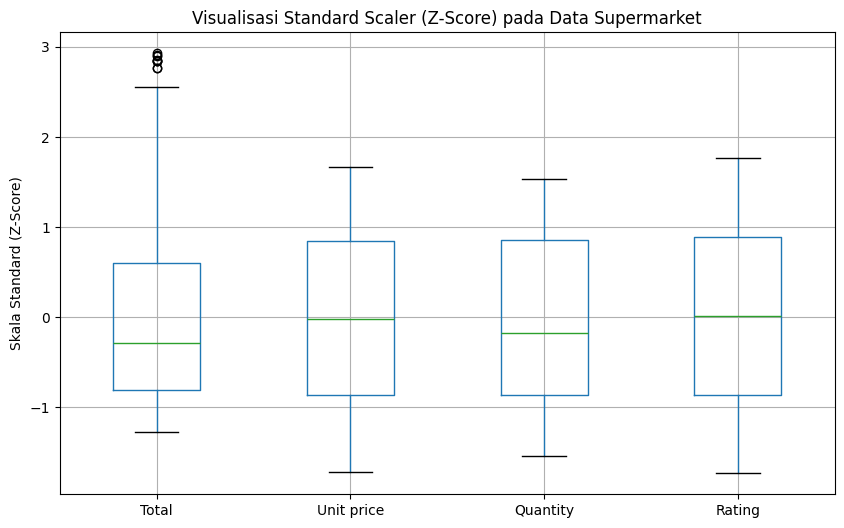

In [ ]:
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Memilih 4 kolom sesuai instruksi
kolom_numerik = ['Total', 'Unit price', 'Quantity', 'Rating']
scaler_std = StandardScaler()

df_std = df_supermarket.copy()
df_std[kolom_numerik] = scaler_std.fit_transform(df_supermarket[kolom_numerik])

# Visualisasi untuk melihat distribusi (Z-Score)
plt.figure(figsize=(10, 6))
df_std[kolom_numerik].boxplot()
plt.title('Visualisasi Standard Scaler (Z-Score) pada Data Supermarket')
plt.ylabel('Skala Standard (Z-Score)')
plt.show()



**Insight Analisis:**

> Lewat metode Standard Scaler ini, kita jadi bisa melihat seberapa jauh sebuah transaksi melenceng dari rata-rata biasanya. Kalau kita perhatikan grafik boxplot-nya, di bagian Total ada beberapa titik yang letaknya jauh di atas. Ini adalah tanda adanya transaksi "raksasa" atau outlier yang nilainya jauh banget dibanding belanjaan orang normal. Kalau data ekstrem seperti ini tidak kita rapikan, hasil perhitungan rata-rata kita bisa jadi kacau dan bikin kita salah menilai daya beli pelanggan yang sebenarnya.

> Tujuan utamanya adalah supaya kita bisa mendeteksi anomali atau data yang "ngaco" dengan lebih mudah. Karena semua angka sudah disamakan skalanya (rata-rata jadi nol), kita bisa langsung tahu mana transaksi yang masih wajar dan mana yang aneh. Ini penting banget dilakukan agar hasil analisis kita nantinya tetap akurat dan tidak tertipu oleh satu atau dua transaksi besar yang jarang banget terjadi.

> Ke depannya, supermarket bisa punya sistem otomatis yang bakal kasih peringatan kalau ada transaksi yang nilainya terlalu ekstrem. Jadi, manajemen bisa langsung cek apakah itu memang ada pelanggan yang borong belanjaan grosir atau malah ada kesalahan sistem di mesin kasir. Dengan cara ini, semua data yang kita punya tetap terjaga kualitasnya dan bisa dipercaya 100% buat ambil keputusan bisnis.

# 3. MinMax Scaller for Exploratory Data Analysis ?
`clue` : lakukan tanpa splitting dataset ke train dan test
- lakukan pada kolom Total, Unit Price, dan tambahkan 2 kolom lainnya
- dan tulis insight dari yang anda dapat dari grafik tersebut

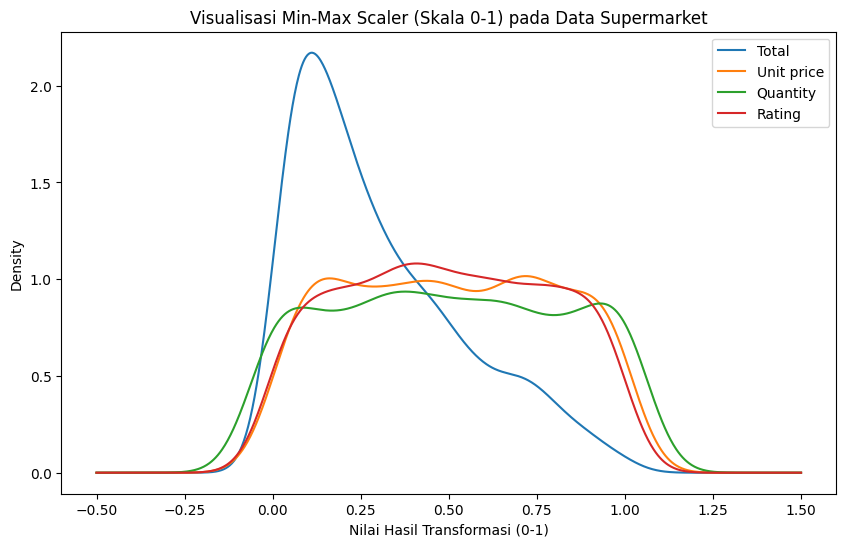

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Memilih 4 kolom numerik sesuai instruksi
kolom_numerik = ['Total', 'Unit price', 'Quantity', 'Rating']
scaler_minmax = MinMaxScaler()

# Proses Scaling (Tanpa Splitting sesuai clue)
df_minmax = df_supermarket.copy()
df_minmax[kolom_numerik] = scaler_minmax.fit_transform(df_supermarket[kolom_numerik])

# Visualisasi KDE Plot untuk melihat perbandingan distribusi
plt.figure(figsize=(10, 6))
df_minmax[kolom_numerik].plot(kind='kde', ax=plt.gca())
plt.title('Visualisasi Min-Max Scaler (Skala 0-1) pada Data Supermarket')
plt.xlabel('Nilai Hasil Transformasi (0-1)')
plt.show()


**Insight Analisis: **
> Melalui Min-Max Scaler, kita berhasil menyamakan "derajat" semua data ke dalam rentang 0 sampai 1. Kalau kita lihat grafik KDE di atas, sekarang kita bisa membandingkan Total (yang aslinya ratusan dolar) dengan Rating (yang aslinya cuma skala 1-10) dalam satu tampilan yang adil. Tanpa teknik ini, kita tidak akan pernah bisa melihat hubungan murni antara harga barang dan kepuasan pelanggan karena angka penjualannya terlalu mendominasi angka rating yang kecil.

> Analisis ini sebenarnya jadi kunci buat kita bikin sistem penilaian produk yang lebih lengkap. Di masa depan, supermarket nggak perlu lagi bingung nentuin produk mana yang paling oke, karena kita bisa gabungin banyak faktor sekaligus—kayak keuntungan, jumlah barang yang laku, sampai tingkat kepuasan pembeli—jadi satu skor tunggal.

> Karena semua datanya sudah kita samakan ke skala 0 sampai 1, kita bisa menjumlahkan semua poin itu dengan adil. Hasilnya, kita bisa bener-bener tahu produk mana yang jadi "Juara" di segala sisi; bukan cuma produk yang sekadar laku atau murah saja, tapi juga produk yang memang disukai dan bikin pelanggan balik lagi. Strategi ini bakal ngebantu manajemen buat fokus ke barang-barang yang bener-bener berkualitas dan paling nguntungin buat bisnis.
